<a href="https://colab.research.google.com/github/famaadotcom/Data-Analytics-Task-1/blob/main/Task%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_12458/654426941.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


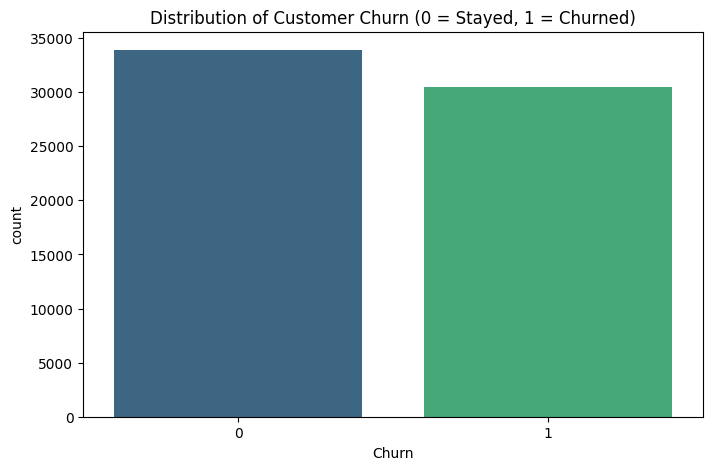

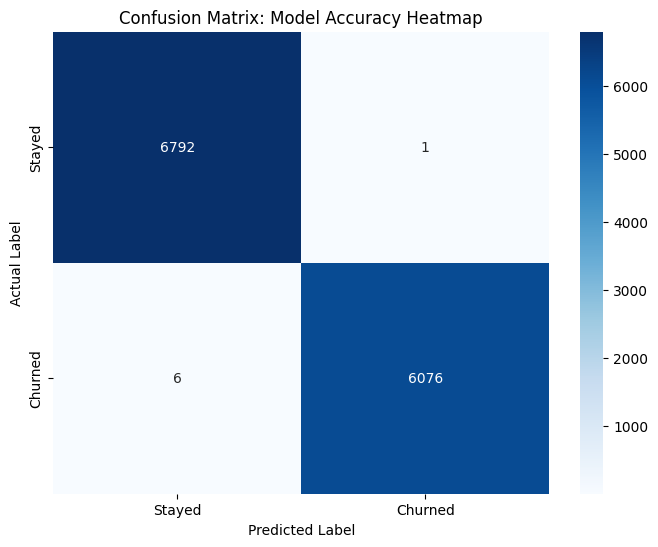

/tmp/ipykernel_12458/654426941.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')


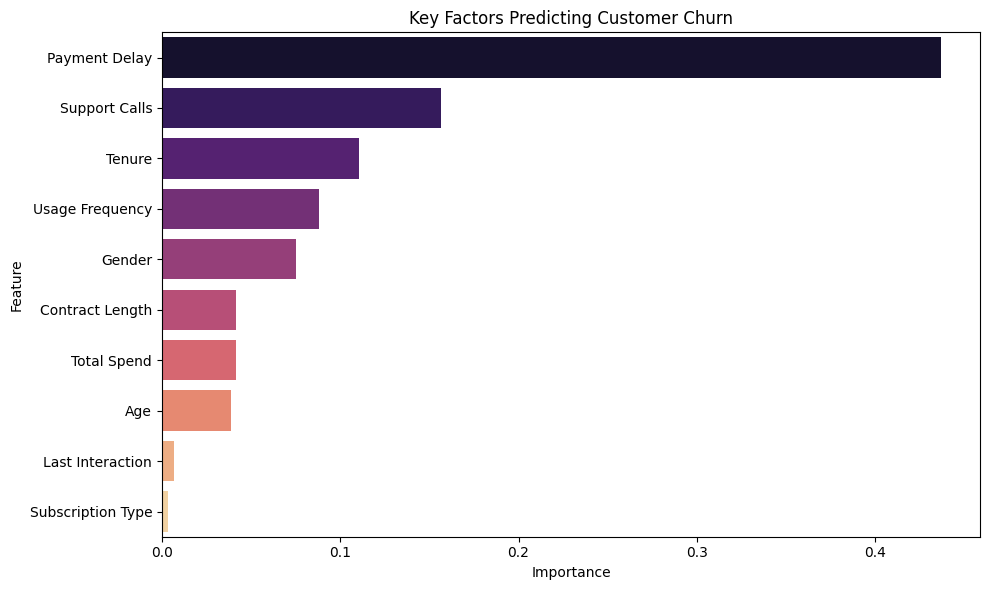

Overall Accuracy: 99.95%

Detailed Performance Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6793
           1       1.00      1.00      1.00      6082

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the dataset
df = pd.read_csv('customer_churn_dataset-testing-master.csv')

# 2. Data Cleaning & Preprocessing
df_clean = df.drop('CustomerID', axis=1).dropna()

# 3. Encoding Categorical Variables
le = LabelEncoder()
cat_cols = ['Gender', 'Subscription Type', 'Contract Length']
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# 4. Define Features (X) and Target (y)
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

# 5. Split and Scale Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train the Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


# 1. Churn Distribution (How many churned vs stayed?)
plt.figure(figsize=(8, 5))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn (0 = Stayed, 1 = Churned)')
plt.show()

# 2. Confusion Matrix (How many did we predict correctly?)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix: Model Accuracy Heatmap')
plt.show()

# 3. Feature Importance (What are the biggest causes of churn?)
importances = model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')
plt.title('Key Factors Predicting Customer Churn')
plt.tight_layout()
plt.show()

# Print metrics to console
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))